## Credit Risk Scoring System – Final Evaluation & Calibration

This notebook evaluates the final risk scores produced by the credit risk model.
It focuses on calibration, early-warning effectiveness, and business cost analysis.

###Summary

This project develops a credit risk scoring model to predict the probability of default using customer demographic, billing, and behavioral data.

The workflow includes data cleaning, feature engineering, model training, validation, and customer risk segmentation. Logistic Regression was used as a baseline for interpretability, while Random Forest captured non-linear behavioral patterns.

Model performance was evaluated using ROC-AUC, and customers were categorized into Low, Medium, and High risk buckets based on predicted default probability.

The final output supports data-driven credit decisions while emphasizing ethical use, transparency, and ongoing model monitoring.

### Model Selection Rationale

Logistic Regression was chosen as a baseline due to its simplicity and interpretability, allowing clear understanding of feature influence on default risk.

Random Forest was selected to capture non-linear relationships and interaction effects in customer behavior.

Using both models provides a balance between explainability and predictive performance.

###Key Risk Drivers

The most important drivers of credit risk identified by the model include:

Recent payment delays and their increasing trend over time

High variability in payment behavior

Elevated bill-to-payment ratios

Recent stress-weighted payment patterns

These features align with real-world credit risk assessment practices.

##Business Impact

Enables proactive identification of high-risk customers

Supports differentiated pricing and credit limit strategies

Helps reduce default losses while expanding credit access responsibly

Provides a scalable framework for ongoing risk monitoring

###Limitations and Future Improvements

Incorporating macroeconomic indicators could improve robustness

Fairness metrics can be added to quantitatively assess bias

Thresholds may be optimized based on business objectives

Model retraining pipelines can be automated for production deployment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path = "/content/drive/MyDrive/Credit_Risk_Project/data/final_scored_customers.csv"
df = pd.read_csv(path)

df.shape
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,default,pay_delay_trend,pay_delay_volatility,pay_trend,recency_weighted_stress,bill_payment_ratio,avg_utilization,risk_score,risk_bucket,recommended_action
0,1,20000,2,2,1,24,2,2,-1,-1,...,1,0.914286,1.861899,4,4.5,11.084892,0.064200,0.535555,Medium Risk,"Monitor monthly, soft nudges"
1,2,120000,2,2,2,26,-1,2,0,0,...,1,-0.257143,1.224745,-3,4.0,3.411306,0.023718,0.289489,Low Risk,Increase credit line / rewards
2,3,90000,2,2,2,34,0,0,0,0,...,0,0.000000,0.000000,0,0.0,9.221063,0.188246,0.103213,Low Risk,Increase credit line / rewards
3,4,50000,2,2,1,37,0,0,0,0,...,0,0.000000,0.000000,0,0.0,27.559447,0.771113,0.107664,Low Risk,Increase credit line / rewards
4,5,50000,1,2,1,57,-1,0,-1,0,...,0,-0.171429,0.516398,-1,-6.5,1.851477,0.364463,0.100850,Low Risk,Increase credit line / rewards


### Final Scored Data Overview

This section verifies the structure and basic statistics of the final scored dataset,
including the distribution of risk scores and default outcomes.


In [ ]:
df[['risk_score', 'default']].describe()

,risk_score,default
count,30000.000000,30000.000000
mean,0.221373,0.221200
std,0.184617,0.415062
min,0.096058,0.000000
25%,0.104359,0.000000
50%,0.123858,0.000000
75%,0.259443,0.000000
max,0.866751,1.000000


Brier Score: 0.13539863891816553


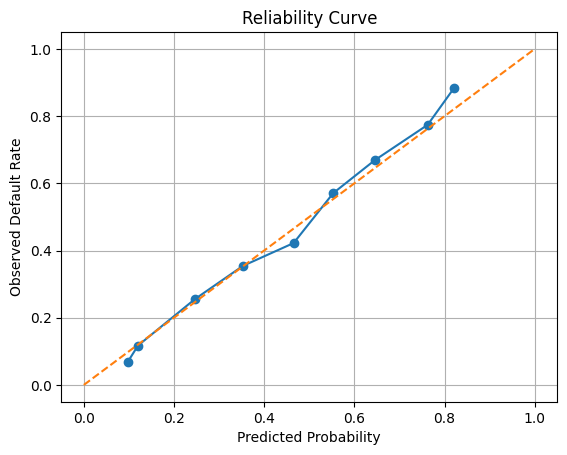

In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Brier Score
brier = brier_score_loss(df['default'], df['risk_score'])
print("Brier Score:", brier)

# Reliability Curve
prob_true, prob_pred = calibration_curve(
    df['default'],
    df['risk_score'],
    n_bins=10
)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Reliability Curve")
plt.grid(True)
plt.show()

In [ ]:
df['risk_decile'] = pd.qcut(
    df['risk_score'],
    10,
    labels=False,
    duplicates='drop'
)
calibration = df.groupby('risk_decile')['default'].mean()
calibration

,default
risk_decile,
0,0.086184
1,0.099875
2,0.105793
3,0.090531
4,0.129667
5,0.144471
6,0.161161
7,0.268195
8,0.432721


### Risk Score Calibration

Customers are grouped into deciles based on predicted risk scores.
For each decile, the observed default rate is computed to assess calibration quality.
A well-calibrated model should show increasing default rates with higher risk deciles.

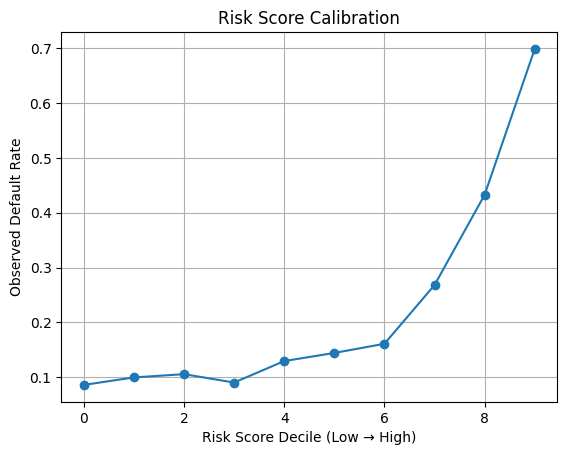

In [ ]:
import matplotlib.pyplot as plt

plt.plot(calibration.index, calibration.values, marker='o')
plt.xlabel("Risk Score Decile (Low → High)")
plt.ylabel("Observed Default Rate")
plt.title("Risk Score Calibration")
plt.grid(True)
plt.show()

The calibration plot confirms that observed default rates increase
monotonically with predicted risk score deciles, indicating good
risk ranking performance.

In [ ]:
early_df = df[
    df['pay_delay_trend'].notnull()
]

pd.qcut(
    early_df['risk_score'],
    3,
    labels=['Low', 'Medium', 'High']
).groupby(early_df['default']).value_counts(normalize=True)

default  risk_score
0        Low           0.387690
         Medium        0.371127
         High          0.241183
1        High          0.657776
         Medium        0.199216
         Low           0.143008
Name: proportion, dtype: float64

### Early Warning Effectiveness

This analysis evaluates how early behavioral signals align with default outcomes.
Higher-risk groups show a greater concentration of defaults, supporting
the model’s usefulness for proactive risk monitoring.

In [ ]:
high_risk = df[df['risk_bucket'] == 'High Risk']

precision_high_risk = high_risk['default'].mean()
precision_high_risk

np.float64(0.7076523031203567)

### High-Risk Segment Precision

This metric represents the probability that a customer classified as
high risk actually defaults, reflecting the reliability of high-risk flags.


In [ ]:
from sklearn.metrics import confusion_matrix

# Define predicted positive (High Risk = 1)
df['pred_high'] = (df['risk_bucket'] == 'High Risk').astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(df['default'], df['pred_high']).ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

# Define business costs
cost_of_missed_default = 100   # False Negative
cost_of_false_alarm = 10       # False Positive

# Correct expected portfolio cost
total_cost = (fn * cost_of_missed_default) + (fp * cost_of_false_alarm)

# Average cost per customer
avg_cost_per_customer = total_cost / len(df)

print("Total Portfolio Cost:", total_cost)
print("Average Cost Per Customer:", avg_cost_per_customer)

TP: 1905
FP: 787
FN: 4731
TN: 22577
Total Portfolio Cost: 480970
Average Cost Per Customer: 16.032333333333334


### Business Cost Interpretation

This simplified cost framework compares the trade-off between missed defaults
and false alarms, demonstrating how model outputs can support
cost-sensitive credit decision-making.

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/day6_evaluated_data.csv",
    index=False
)

print("Evaluation data saved.")

Evaluation data saved.


### Conclusion

The final evaluation demonstrates that the credit risk scoring model
produces well-calibrated risk estimates, effective early-warning signals,
and actionable insights for business decision-making.